In [24]:
# %% [markdown]
# # Stage 2 Preprocessing — filtering, bad channels, ICA
#
# Loads the stage-1 checkpoint, applies filtering, detects/interpolates bad
# channels, runs ICA + ICLabel for ocular artifact removal, and saves a
# stage-2 checkpoint plus an HTML report (via `mne.Report`) documenting every
# step for later QC / group-level review.
#
# Run cells top to bottom. Cells that need an interactive matplotlib backend
# (`%matplotlib qt`) are marked — run that magic once per kernel session.

# %% Cell 1 — Imports
import os
# os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import time

import mne
from mne.preprocessing import ICA
from mne_icalabel import label_components
from pyprep import NoisyChannels

def status(msg):
    print(f"\n[{time.strftime('%H:%M:%S')}] {msg}")

In [25]:
# %% Cell 2 — Config & load stage-1 checkpoint
mne.set_log_level("WARNING")

CONFIG = {
    "results_dir": Path(r"/Volumes/Misophonia_EEG"),
    "subject": "103"
}

sub = CONFIG["subject"]
status(f"Loading stage-1 checkpoint for subject {sub}...")
out_dir = CONFIG["results_dir"] / sub

raw = mne.io.read_raw_fif(out_dir / f"{sub}_stage1_resampled_raw.fif", preload=True)
events = np.load(out_dir / f"{sub}_stage1_events.npy")
with open(out_dir / f"{sub}_stage1_event_id.json") as f:
    event_id = json.load(f)

sfreq = raw.info["sfreq"]
first_t = (events[0, 0] - raw.first_samp) / sfreq
last_t = (events[-1, 0] - raw.first_samp) / sfreq

tmin = max(0.0, first_t - 10.0)
tmax = min(raw.times[-1], last_t + 10.0)

montage = raw.get_montage()

print(f"Loaded: {raw.info['sfreq']} Hz, {len(raw.ch_names)} channels, {len(events)} events")
print("event_id:", event_id)
print(f"Montage: {len(montage.ch_names) if montage else 0} positions")

print(f"\nTotal events: {len(events)}")
for label, code in event_id.items():
    count = np.sum(events[:, 2] == code)
    print(f"  {label}: {count}")


[15:32:46] Loading stage-1 checkpoint for subject 103...
Loaded: 250.0 Hz, 35 channels, 202 events
event_id: {'Unpleasant': 1, 'Neutral': 2, 'Pleasant': 4, 'Unpleasant_noise': 8, 'Pleasant_noise': 16}
Montage: 32 positions

Total events: 202
  Unpleasant: 41
  Neutral: 40
  Pleasant: 41
  Unpleasant_noise: 40
  Pleasant_noise: 40



[15:33:43] Computing PSD before filtering (this can take a moment)...


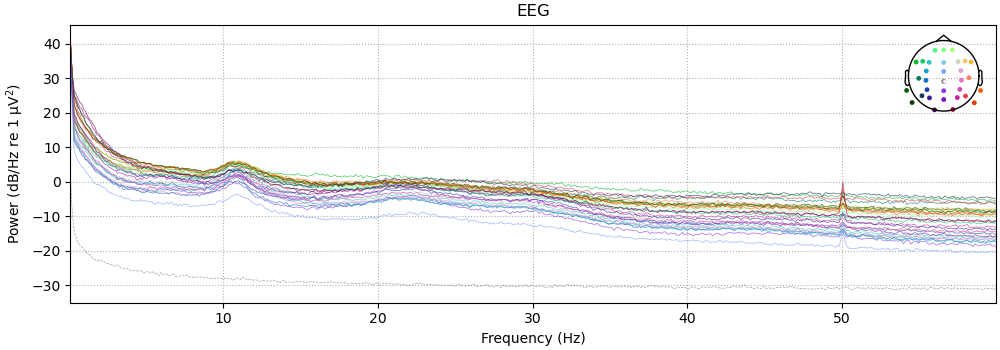

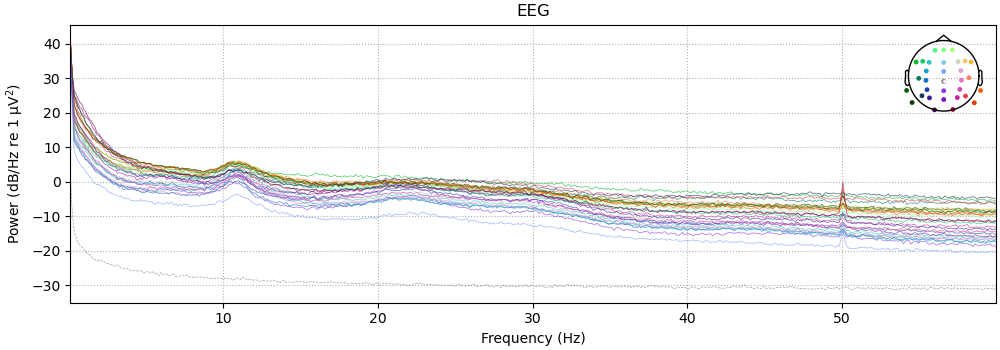

In [26]:
# %% Cell 3 — Start the HTML report
# mne.Report is MNE's built-in logging/QC tool: add_* calls append sections
# (figures, raw summaries, ICA panels, arbitrary HTML) and report.save()
# at the end writes one navigable HTML file with a sidebar per section.
%matplotlib widget
status("Computing PSD before filtering (this can take a moment)...")
report = mne.Report(title=f"Stage 2 Preprocessing — Subject {sub}")
report.add_raw(raw, title="Stage 1 checkpoint (as loaded)", psd=False)

psd_prefilter = raw.compute_psd(
    method="welch", fmin=0.05, fmax=60, picks="eeg",
    n_fft=2048, n_overlap=1024, average="median",
)
fig_psd_prefilter = psd_prefilter.plot(picks="eeg", exclude=[], dB=True)
report.add_figure(fig_psd_prefilter, title="PSD before filtering")

In [27]:
# %% Cell 5 — Filtering: high-pass -> notch -> low-pass (order matters)
status("Applying high-pass -> notch -> low-pass filters...")
raw.filter(l_freq=0.1, h_freq=None, picks="eeg", fir_design="firwin", phase="zero")
raw.notch_filter(freqs=50, picks="eeg", notch_widths=1, fir_design="firwin")
raw.filter(l_freq=None, h_freq=40, picks="eeg", fir_design="firwin", phase="zero")

print(f"Filtered: {raw.info['highpass']}-{raw.info['lowpass']} Hz (notch at 50 Hz)")

report.add_html(
    f"<p>High-pass 0.1 Hz &rarr; notch 50 Hz (width 1 Hz) &rarr; low-pass 40 Hz</p>",
    title="Filtering applied",
)


[15:33:51] Applying high-pass -> notch -> low-pass filters...
Filtered: 0.1-40.0 Hz (notch at 50 Hz)



[15:33:59] Computing PSD after filtering...


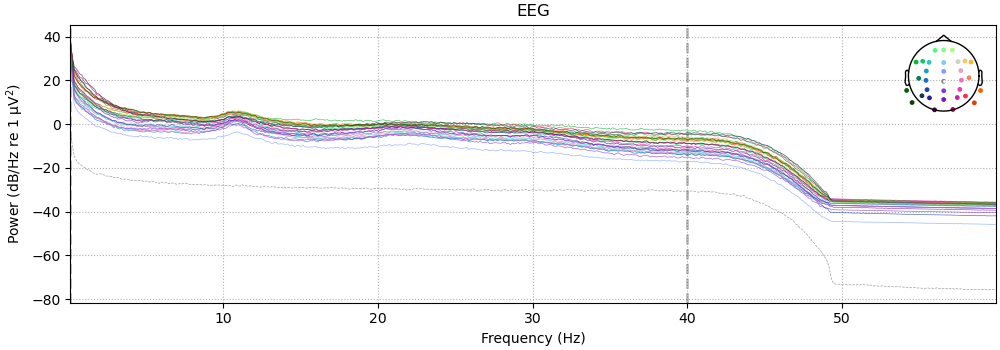

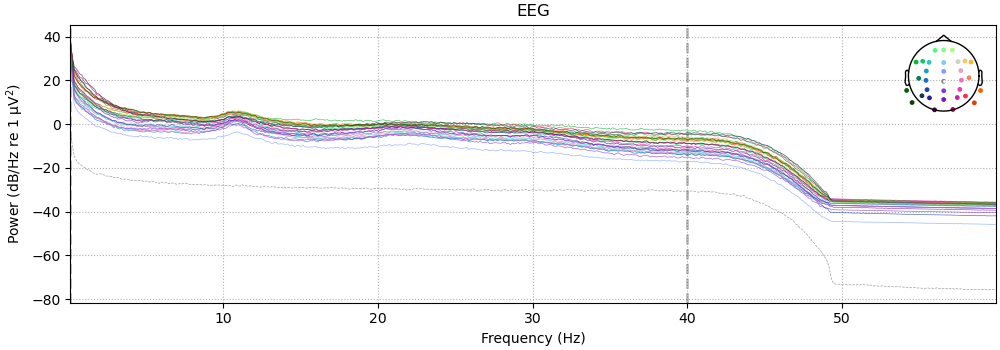

In [28]:
# %% Cell 6 — Interactive PSD check (post-filter)
# Run `%matplotlib qt` as its own line/cell once per session for a zoomable
# window; otherwise this still renders inline.
#%matplotlib qt
status("Computing PSD after filtering...")
psd = raw.compute_psd(
    method="welch", fmin=0.05, fmax=60, picks="eeg",
    n_fft=2048, n_overlap=1024, average="median",
)
fig_psd = psd.plot(picks="eeg", exclude=[], dB=True)
report.add_figure(fig_psd, title="PSD after filtering")

In [29]:
# %% Cell 4 — Reset bads carried from stage 1
stage1_bads = list(raw.info["bads"])
print("Bads carried from stage 1:", stage1_bads)
raw.info["bads"] = []
print("Reset. Current bads:", raw.info["bads"])

report.add_html(
    f"<p>Bads carried from stage 1: {stage1_bads or 'none'} &rarr; reset to empty list.</p>",
    title="Reset bad channels from stage 1",
)


Bads carried from stage 1: ['Cz']
Reset. Current bads: []


In [30]:
# %% Cell 7 — automated bad segment deletion

# Automated:
dur_before_crop = raw.times[-1]
raw.crop(tmin=tmin, tmax=tmax)
status("Trimmed 10 seconds from beginning and end of triggers.")

report.add_html(
    f"<p>Kept {tmin:.1f}&ndash;{tmax:.1f} s (first trigger &minus; 10 s to last trigger + 10 s).</p>"
    f"<p>Duration: {dur_before_crop:.1f} s &rarr; {raw.times[-1]:.1f} s</p>",
    title="Automatically crop bad segments",
)



[15:34:10] Trimmed 10 seconds from beginning and end of triggers.


In [31]:
# %% Cell 8 — Automated bad channel detection (pyprep) + interpolation
MAX_BADS = 4

DROP_CHANNELS = ["F11", "F12", "FT11", "FT12"]  #  "FP1", "FP2"
raw.drop_channels(DROP_CHANNELS)
status(f"Dropped channels {DROP_CHANNELS}.")
report.add_html(
    f"<p>Dropped channels: {DROP_CHANNELS}</p>"
    f"<p>Remaining EEG channels: {len(mne.pick_types(raw.info, eeg=True))}</p>",
    title="Dropped bad channels",
)

status("Running automated bad-channel detection (pyprep RANSAC) — this is usually the slowest step, can take a few minutes...")
raw.set_eeg_reference(ref_channels="average", projection=False)
nc = NoisyChannels(raw.copy(), random_state=35)
nc.find_all_bads(ransac=True)
bads = nc.get_bads(verbose=True)

criteria = {
    "correlation": nc.bad_by_correlation,
    "deviation": nc.bad_by_deviation,
    "hf_noise": nc.bad_by_hf_noise,
    "ransac": nc.bad_by_ransac,
    "nan": nc.bad_by_nan,
    "flat": nc.bad_by_flat,
    "snr": nc.bad_by_SNR,
    "dropout": nc.bad_by_dropout,
    "psd": nc.bad_by_psd,
    "manual": nc.bad_by_manual,
}

print(f"Bad channels detected (single pass, post-reference): {bads}")
for name, chs in criteria.items():
    if chs:
        print(f"  by {name}: {chs}")
status("Bad-channel detection complete.")


[15:34:16] Dropped channels ['F11', 'F12', 'FT11', 'FT12'].

[15:34:16] Running automated bad-channel detection (pyprep RANSAC) — this is usually the slowest step, can take a few minutes...
Bad channels detected (single pass, post-reference): ['T7', 'F7', 'T8']
  by correlation: ['F7', 'T7', 'T8']

[15:34:42] Bad-channel detection complete.


In [32]:
if len(bads) <= MAX_BADS:
    raw.info["bads"] = bads
    if bads:
        raw.interpolate_bads(reset_bads=True)
        raw.set_eeg_reference(ref_channels="average", projection=False)
    print(f"Done. Interpolated: {bads}")

report.add_html(
    f"<p>Detected: {bads}</p><pre>{json.dumps(criteria, indent=2)}</pre>"
    f"<p>Flagged for manual review: {len(bads) > MAX_BADS}</p>",
    title="Bad channel detection (pyprep)",
)

if len(bads) > MAX_BADS:
    report_html_path = out_dir / f"{sub}_stage2_report.html"
    report.save(report_html_path, overwrite=True, open_browser=False)
    print(f"Saved (partial, flagged): {report_html_path}")
    raise RuntimeError(
        f"FLAGGED: {len(bads)} bad channels ({bads}) exceeds MAX_BADS={MAX_BADS} "
        "— stopping for manual review. Re-run Cell 7 to inspect/mark manually, "
        "or raise MAX_BADS if this subject is expected to be noisier."
    )

Done. Interpolated: ['T7', 'F7', 'T8']


In [33]:
# %% Cell 9 — ICA fit
# Fit on a 1 Hz high-pass copy (better decomposition) — never fit on your
# analysis-filtered data.
status("Fitting ICA (infomax, 20 components)...")
raw_ica_fit = raw.copy().filter(l_freq=1.0, h_freq=None, picks="eeg", fir_design="firwin")
ica = ICA(n_components=20, method="infomax", fit_params=dict(extended=True),
          random_state=35, max_iter=800)
ica.fit(raw_ica_fit, picks="eeg")
print(f"ICA fit complete: {ica.n_components_} components")


[15:34:50] Fitting ICA (infomax, 20 components)...
ICA fit complete: 20 components



[15:36:38] Rendering ICA component topographies...


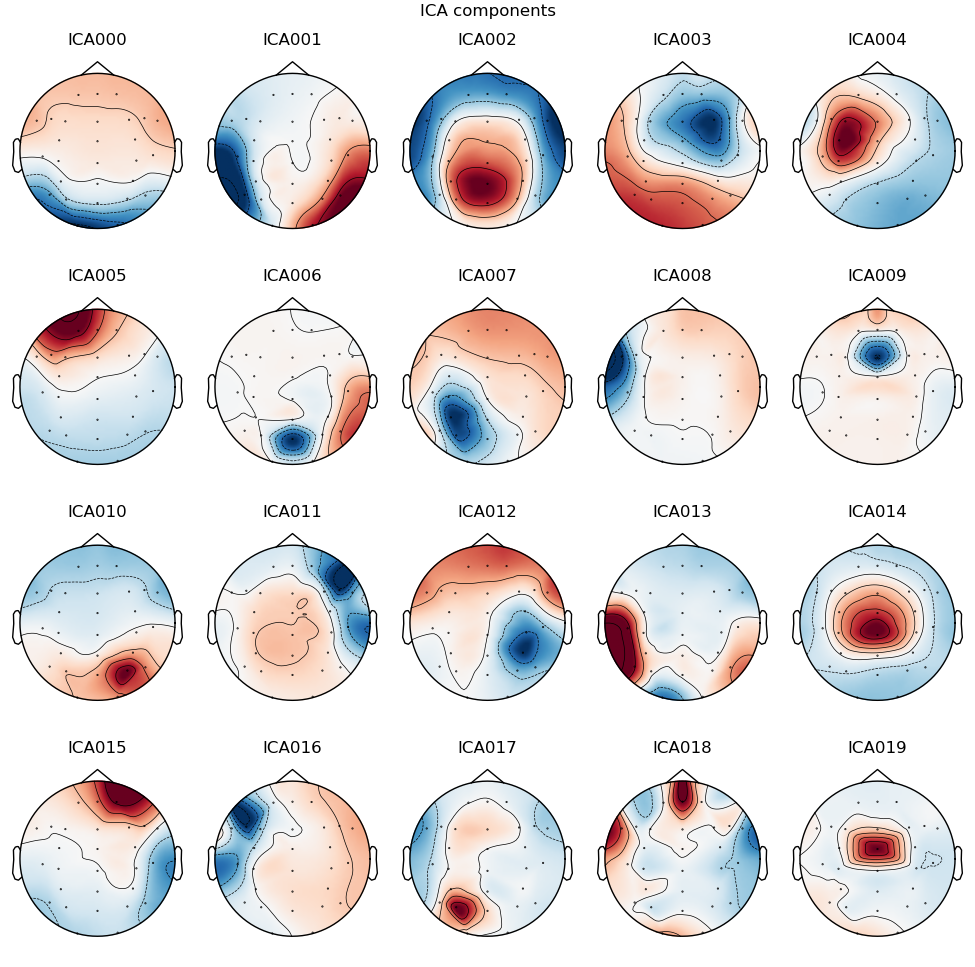

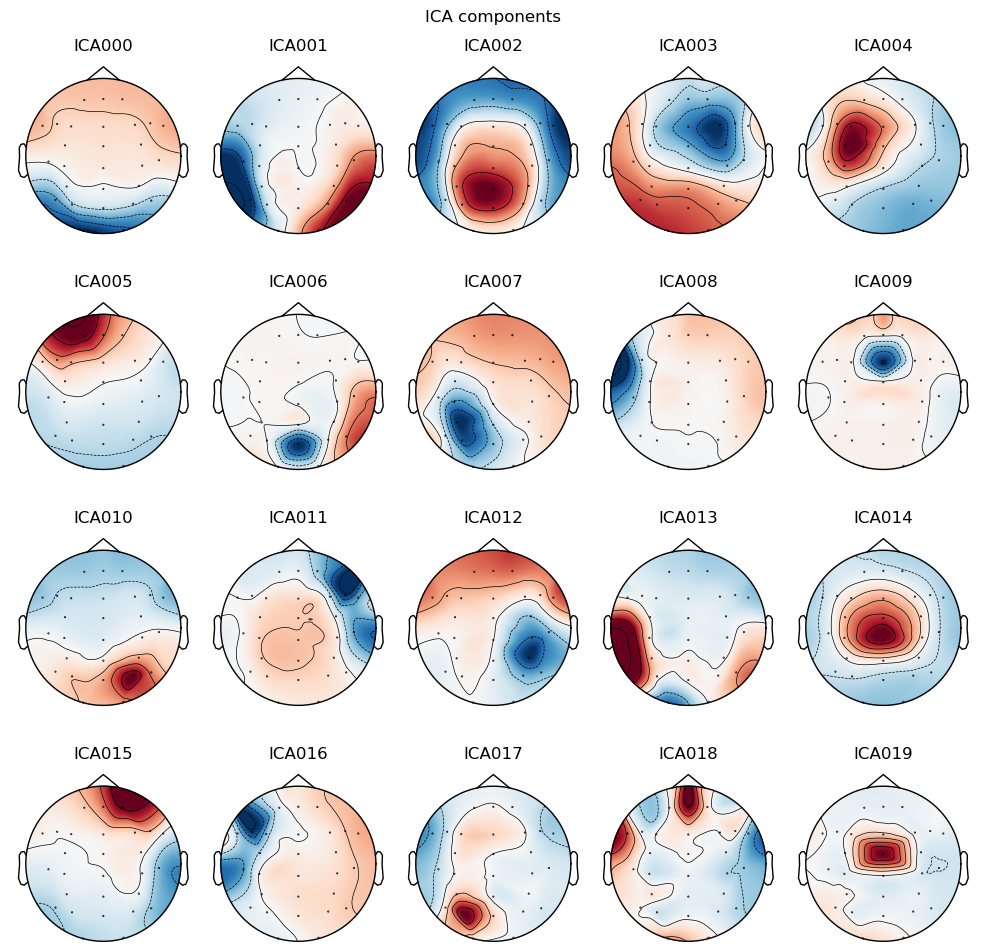

In [34]:
# %% Cell 10 — Inspect components visually
status("Rendering ICA component topographies...")
ica.plot_components()

In [35]:
# %% Cell 11 — ICLabel classification
status("Running ICLabel classification...")
matplotlib.use("Agg")

raw_iclabel = raw.copy().filter(l_freq=1.0, h_freq=40.0, picks="eeg", fir_design="firwin")
ic_labels = label_components(raw_iclabel, ica, method="iclabel")

print("Labels:", ic_labels["labels"])
print("Probabilities:", ic_labels["y_pred_proba"])

eog_iclabel_indices = [
    i for i, (label, prob) in enumerate(zip(ic_labels["labels"], ic_labels["y_pred_proba"]))
    if label == "eye blink" and prob > 0.8
]
print(f"ICLabel-flagged eye components (prob > 0.8): {eog_iclabel_indices}")

# Setting ica.exclude *before* add_ica makes the report include the
# "original vs. cleaned" overlay, and marks the excluded components in the
# topography grid (add_ica already renders all component topographies, so
# the Cell 10 plot doesn't need adding separately).
ica.exclude = list(eog_iclabel_indices)
report.add_ica(
    ica,
    title="ICA decomposition",
    inst=raw_iclabel,
    picks=eog_iclabel_indices if eog_iclabel_indices else None,
)

# ICLabel table: one row per component, excluded ones highlighted
iclabel_df = pd.DataFrame({
    "component": [f"ICA{i:03d}" for i in range(ica.n_components_)],
    "label": ic_labels["labels"],
    "probability": np.round(ic_labels["y_pred_proba"], 3),
    "excluded": [i in eog_iclabel_indices for i in range(ica.n_components_)],
})
report.add_html(
    iclabel_df.style
    .apply(lambda r: ["background-color: #fdd" if r["excluded"] else "" for _ in r], axis=1)
    .hide(axis="index")
    .to_html(),
    title="ICLabel classification",
)


[15:36:50] Running ICLabel classification...


/var/folders/p2/wzmbs6kj56l8yzqpnwvd311r0000gn/T/ipykernel_32039/4246661287.py:6: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_iclabel, ica, method="iclabel")


Labels: ['brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'muscle artifact', 'brain', 'brain', 'brain', 'brain', 'other', 'brain', 'other', 'brain', 'brain', 'other', 'brain']
Probabilities: [0.84952414 0.45924395 0.99556553 0.99967086 0.9998756  0.8796278
 0.7607218  0.963032   0.41211125 0.5672107  0.92365646 0.99641323
 0.99678534 0.4272086  0.99939543 0.5260514  0.878104   0.8476757
 0.9650321  0.9163276 ]
ICLabel-flagged eye components (prob > 0.8): []


In [36]:
# %% Cell 12 — Apply ICA (remove flagged ocular components)
status("Applying ICA — removing flagged ocular components from raw...")
ica.apply(raw, exclude=eog_iclabel_indices)
print(f"Applied ICA. Removed components: {eog_iclabel_indices}")

var_removed = (
    ica.get_explained_variance_ratio(raw_ica_fit, components=eog_iclabel_indices, ch_type="eeg")["eeg"]
    if eog_iclabel_indices else 0.0
)
report.add_html(
    f"<p>Removed components: {eog_iclabel_indices or 'none'}</p>"
    f"<p>Variance explained by removed components: {var_removed:.1%}</p>",
    title="ICA applied",
)



[15:37:38] Applying ICA — removing flagged ocular components from raw...
Applied ICA. Removed components: []


In [37]:
# %% Cell 13 — Save stage-2 checkpoint, JSON report, ICA solution, and HTML report
status("Saving stage-2 outputs (raw, JSON report, ICA solution, HTML report)...")
stage2_raw_path = out_dir / f"{sub}_stage2_cleaned_raw.fif"
raw.save(stage2_raw_path, overwrite=True)
print(f"Saved: {stage2_raw_path}")

stage2_report = {
    "subject": sub,
    "bads_detected": bads,
    "bads_criteria": criteria,
    "n_bads": len(bads),
    "flagged_for_review": len(bads) > MAX_BADS,
    "highpass_hz": raw.info["highpass"],
    "lowpass_hz": raw.info["lowpass"],
    "ica_eog_components_removed": list(map(int, eog_iclabel_indices)),
    "n_ica_components": ica.n_components_,
}
with open(out_dir / f"{sub}_stage2_report.json", "w") as f:
    json.dump(stage2_report, f, indent=2)
print(f"Saved: {out_dir / f'{sub}_stage2_report.json'}")

ica.save(out_dir / f"{sub}_stage2_ica.fif", overwrite=True)
print(f"Saved: {out_dir / f'{sub}_stage2_ica.fif'}")

report_html_path = out_dir / f"{sub}_stage2_report.html"
report.save(report_html_path, overwrite=True, open_browser=False)
print(f"Saved: {report_html_path}")


[15:37:42] Saving stage-2 outputs (raw, JSON report, ICA solution, HTML report)...
Saved: /Volumes/Misophonia_EEG/103/103_stage2_cleaned_raw.fif
Saved: /Volumes/Misophonia_EEG/103/103_stage2_report.json
Saved: /Volumes/Misophonia_EEG/103/103_stage2_ica.fif
Saved: /Volumes/Misophonia_EEG/103/103_stage2_report.html
